# Tugas Analisis Numerik: Regresi & Pencarian Akar

## Nama  : Sayyidah Afifatuz Zahro
## NPM   : 25083010004
## Kelas : Analisis Numerik (A)

Lima gerai dengan strategi marketing berbeda:

| Gerai | Strategi | Karakteristik |
|---|---|---|
| A | Premium Gourmet | Harga tinggi, niche terbatas, kafe *specialty* |
| B | Mass Market Volume | Harga murah, margin tertekan inflasi bahan |
| C | Promo Agresif | Diskon awal, iklan moderate-high |
| D | Mall Premium Flagship | Sewa lokasi tinggi |
| E | Cloud Kitchen | Fokus *app delivery*, komisi platform 18% |

**Alur pengerjaan:**
1. Muat & eksplorasi data
2. Plot *Jumlah Penjualan* vs *Revenue* untuk tiap gerai
3. Regresi untuk menemukan bentuk fungsional Revenue(volume) dan Biaya Total(volume)
4. Pencarian akar $f(x) = \text{Revenue}(x) - \text{Biaya Total}(x) = 0$ untuk menemukan **Break-Even Point (BEP)**, menggunakan metode Bisection dan Newton-Raphson (diimplementasikan manual, lalu divalidasi dengan `scipy.optimize.brentq`)
5. Kesimpulan & interpretasi bisnis


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq
import io
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Memuat & Mengeksplorasi Data


In [ ]:
import io
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
from scipy.optimize import brentq, curve_fit

warnings.filterwarnings("ignore")

# Pengaturan tampilan grafik
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Upload file CSV secara manual
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Kode pemrosesan data selanjutnya:
df["Tanggal"] = pd.to_datetime(df["Tanggal"])
df["Total Biaya (Rp)"] = df["Biaya Variabel (Rp)"] + df["Fixed Cost Harian (Rp)"]

print(df.shape)
df.head()

Saving sintesis_data_donat_harian.csv to sintesis_data_donat_harian (3).csv
(450, 9)


,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp),Total Biaya (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833,2422833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833,2371833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667,2618333
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167,2694833
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333,2482333


### Penjelasan : Konversi Tanggal mengubah teks tanggal biasa menjadi format tanggal resmi Python supaya data bisa diurutkan dan dibuat grafik tren harian tanpa error. Sementara itu, pembuatan kolom baru berfungsi menghitung Total Biaya secara otomatis dengan menjumlahkan Biaya Variabel dan Fixed Cost di setiap barisnya.

In [ ]:
# Ringkasan statistik per gerai
ringkasan = df.groupby("Gerai").agg(
    Harga_Jual=("Harga Jual (Rp)", "first"),
    Vol_Min=("Jumlah Terjual (Unit)", "min"),
    Vol_Max=("Jumlah Terjual (Unit)", "max"),
    Vol_Mean=("Jumlah Terjual (Unit)", "mean"),
    Fixed_Cost=("Fixed Cost Harian (Rp)", "first"),
    Balance_Mean=("Balance (Rp)", "mean"),
    Hari_Rugi=("Balance (Rp)", lambda s: (s < 0).sum()),
).round(1)
ringkasan

,Harga_Jual,Vol_Min,Vol_Max,Vol_Mean,Fixed_Cost,Balance_Mean,Hari_Rugi
Gerai,,,,,,,
Gerai A,25000,81,131,99.1,1683333,-48183.0,59
Gerai B,8000,435,710,527.5,733333,1292267.0,0
Gerai C,11000,220,522,328.9,1733333,292896.3,28
Gerai D,20000,103,223,149.8,2666666,-748799.3,86
Gerai E,15000,153,332,226.6,800000,1171806.7,0


In [ ]:
# --- Interpretasi otomatis dari tabel ringkasan ---
gerai_termahal = ringkasan["Harga_Jual"].idxmax()
gerai_termurah = ringkasan["Harga_Jual"].idxmin()
gerai_vol_tertinggi = ringkasan["Vol_Mean"].idxmax()
gerai_vol_terendah = ringkasan["Vol_Mean"].idxmin()
gerai_fc_tertinggi = ringkasan["Fixed_Cost"].idxmax()
gerai_paling_rugi = ringkasan["Hari_Rugi"].idxmax()

print("INTERPRETASI:")
print(f"- Harga jual tertinggi : {gerai_termahal} (Rp{ringkasan.loc[gerai_termahal,'Harga_Jual']:,.0f}/unit) "
      f"-> sesuai posisinya sebagai gerai premium.")
print(f"- Harga jual terendah  : {gerai_termurah} (Rp{ringkasan.loc[gerai_termurah,'Harga_Jual']:,.0f}/unit) "
      f"-> strategi volume, mengandalkan banyak transaksi.")
print(f"- Volume rata-rata tertinggi : {gerai_vol_tertinggi} ({ringkasan.loc[gerai_vol_tertinggi,'Vol_Mean']:.0f} unit/hari)")
print(f"- Volume rata-rata terendah  : {gerai_vol_terendah} ({ringkasan.loc[gerai_vol_terendah,'Vol_Mean']:.0f} unit/hari)")
print(f"- Fixed cost harian tertinggi: {gerai_fc_tertinggi} (Rp{ringkasan.loc[gerai_fc_tertinggi,'Fixed_Cost']:,.0f}/hari) "
      f"-> beban tetap besar ini yang nanti akan menaikkan titik impasnya.")
print(f"- Gerai dengan hari rugi terbanyak: {gerai_paling_rugi} "
      f"({int(ringkasan.loc[gerai_paling_rugi,'Hari_Rugi'])} dari {df[df.Gerai==gerai_paling_rugi].shape[0]} hari) "
      f"-> mengindikasikan volume hariannya sering berada di bawah titik impas.")


INTERPRETASI:
- Harga jual tertinggi : Gerai A (Rp25,000/unit) -> sesuai posisinya sebagai gerai premium.
- Harga jual terendah  : Gerai B (Rp8,000/unit) -> strategi volume, mengandalkan banyak transaksi.
- Volume rata-rata tertinggi : Gerai B (528 unit/hari)
- Volume rata-rata terendah  : Gerai A (99 unit/hari)
- Fixed cost harian tertinggi: Gerai D (Rp2,666,666/hari) -> beban tetap besar ini yang nanti akan menaikkan titik impasnya.
- Gerai dengan hari rugi terbanyak: Gerai D (86 dari 90 hari) -> mengindikasikan volume hariannya sering berada di bawah titik impas.


## 2. Plot Jumlah Penjualan vs Revenue

Setiap gerai diplot sebagai *scatter plot* volume penjualan harian (unit) terhadap
pendapatan kotor (revenue) harian.

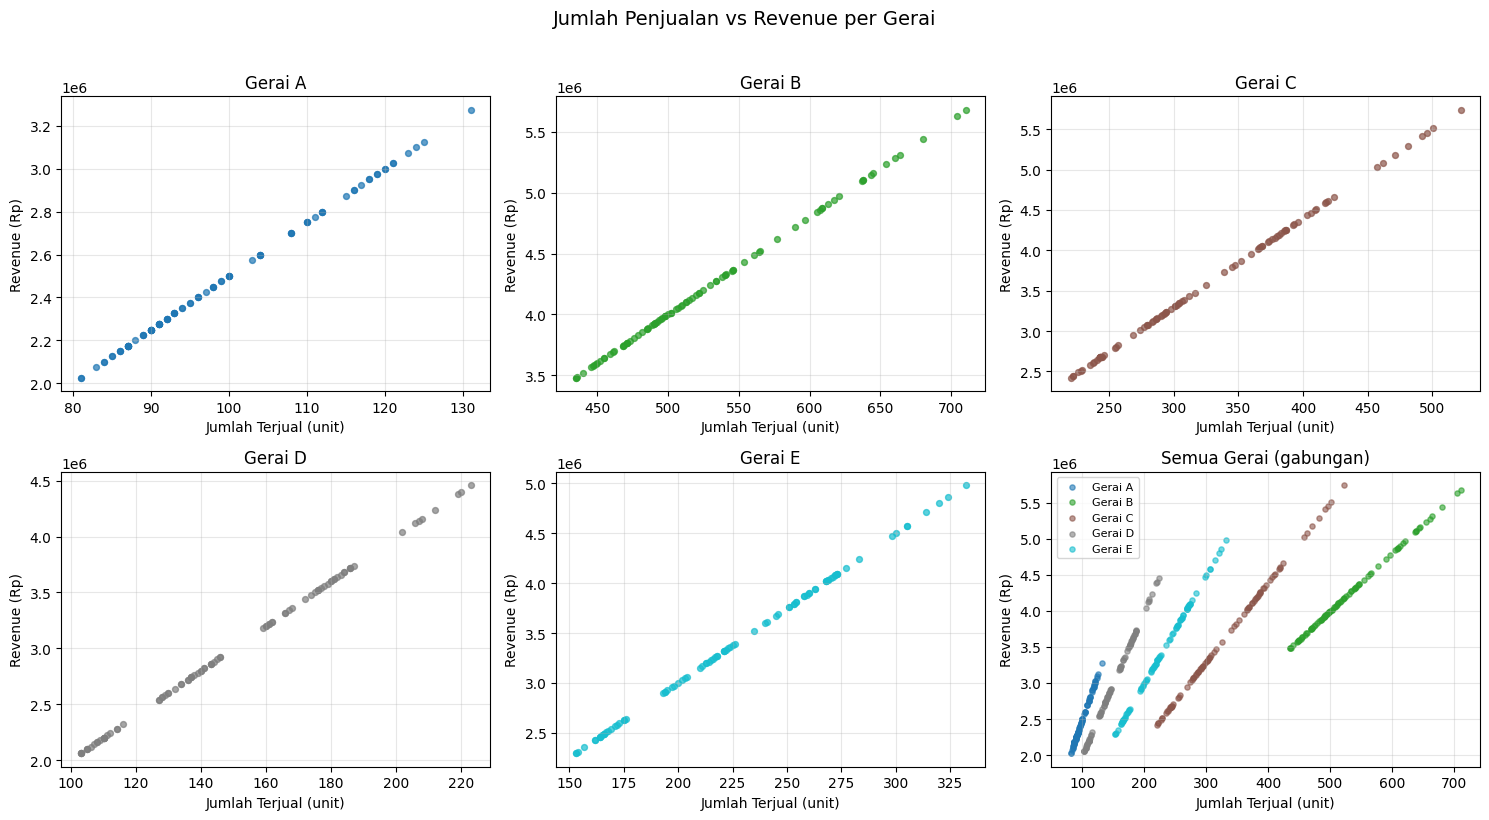

In [ ]:
gerai_list = sorted(df["Gerai"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(gerai_list)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, g in enumerate(gerai_list):
    sub = df[df["Gerai"] == g]
    axes[i].scatter(sub["Jumlah Terjual (Unit)"], sub["Pendapatan Kotor (Rp)"],
                     s=18, alpha=0.7, color=colors[i])
    axes[i].set_title(g)
    axes[i].set_xlabel("Jumlah Terjual (unit)")
    axes[i].set_ylabel("Revenue (Rp)")

# gabungan semua gerai di panel terakhir
ax = axes[-1]
for i, g in enumerate(gerai_list):
    sub = df[df["Gerai"] == g]
    ax.scatter(sub["Jumlah Terjual (Unit)"], sub["Pendapatan Kotor (Rp)"],
               s=14, alpha=0.6, color=colors[i], label=g)
ax.set_title("Semua Gerai (gabungan)")
ax.set_xlabel("Jumlah Terjual (unit)")
ax.set_ylabel("Revenue (Rp)")
ax.legend(fontsize=8)

plt.suptitle("Jumlah Penjualan vs Revenue per Gerai", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi grafik:**

Titik-titik pada setiap panel membentuk pola **garis lurus naik** (bukan melengkung
atau menyebar acak). Ini masuk akal karena harga jual per unit di tiap gerai konstan
dari hari ke hari, jadi:

$$\text{Revenue} = \text{Harga} \times \text{Volume}$$

adalah hubungan proporsional (linear) secara alami — semakin curam kemiringan garis
titik-titiknya, semakin tinggi harga jual gerai tersebut (bandingkan Gerai A yang
titiknya menanjak tajam meski volumenya kecil, dengan Gerai B yang titiknya lebih
landai tapi tersebar di volume yang jauh lebih besar). Pola inilah yang jadi *sinyal
awal* sebelum masuk ke tahap regresi: kita menduga model **linear** kemungkinan besar
akan jadi model terbaik dan dugaan ini akan diuji secara kuantitatif pada bagian
berikutnya.

## 3. Regresi: Bentuk Tren Revenue terhadap Volume Penjualan

Beberapa kandidat model dicoba untuk masing-masing gerai, lalu dipilih model terbaik
berdasarkan *Adjusted R²* (agar model dengan parameter lebih banyak tidak otomatis menang
hanya karena lebih fleksibel):

- Linear: $y = ax + b$
- Kuadratik: $y = ax^2 + bx + c$
- Kubik: $y = ax^3 + bx^2 + cx + d$
- Eksponensial: $y = a e^{bx} + c$

Hal yang sama juga dilakukan untuk **Biaya Total** (Biaya Variabel + Fixed Cost) terhadap
volume, karena kurva biaya inilah yang akan diadu dengan kurva revenue untuk mencari BEP.

In [ ]:
def f_lin(x, a, b):
    return a * x + b

def f_quad(x, a, b, c):
    return a * x**2 + b * x + c

def f_cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def f_expo(x, a, b, c):
    return a * np.exp(b * x) + c

MODELS = {
    "Linear":       (f_lin,   2),
    "Kuadratik":    (f_quad,  3),
    "Kubik":        (f_cubic, 4),
    "Eksponensial": (f_expo,  3),
}

def r_squared(y, y_hat):
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

def adjusted_r2(r2, n, k):
    if n - k - 1 <= 0:
        return r2
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

def cari_model_terbaik(x, y, verbose_name=""):
    """Fit semua model kandidat, kembalikan dict hasil + nama model terbaik (adj R2 tertinggi)."""
    hasil = {}
    for nama, (fn, k) in MODELS.items():
        try:
            if nama == "Eksponensial":
                p0 = [1.0, 1e-3, float(np.min(y))]
                popt, _ = curve_fit(fn, x, y, p0=p0, maxfev=30000)
            else:
                popt, _ = curve_fit(fn, x, y, maxfev=30000)
            y_hat = fn(x, *popt)
            r2 = r_squared(y, y_hat)
            ar2 = adjusted_r2(r2, len(x), k)
            hasil[nama] = {"fn": fn, "popt": popt, "r2": r2, "adj_r2": ar2}
        except Exception:
            continue
    terbaik = max(hasil, key=lambda k: hasil[k]["adj_r2"])
    return terbaik, hasil


Kode ini digunakan untuk menguji dan membandingkan empat model regresi (Linear, Kuadratik, Kubik, dan Eksponensial) secara otomatis. Pemilihan model terbaik didasarkan pada nilai Adjusted R-Squared ($\text{Adj } R^2$) tertinggi untuk memastikan rumus yang digunakan memiliki tingkat akurasi paling presisi dalam memprediksi biaya dan menghitung titik impas (break-even point).

In [ ]:
regresi_revenue = {}   # simpan hasil regresi revenue per gerai
regresi_biaya   = {}   # simpan hasil regresi biaya total per gerai

print(f"{'Gerai':10s} | {'Model Revenue':13s} {'R2':>8s} {'AdjR2':>8s} | {'Model Biaya':13s} {'R2':>8s} {'AdjR2':>8s}")
print("-"*80)

for g in gerai_list:
    sub = df[df["Gerai"] == g].sort_values("Jumlah Terjual (Unit)")
    x = sub["Jumlah Terjual (Unit)"].values.astype(float)
    y_rev = sub["Pendapatan Kotor (Rp)"].values.astype(float)
    y_cost = sub["Total Biaya (Rp)"].values.astype(float)

    nama_r, hasil_r = cari_model_terbaik(x, y_rev)
    nama_c, hasil_c = cari_model_terbaik(x, y_cost)

    regresi_revenue[g] = {"x": x, "y": y_rev, "nama": nama_r, **hasil_r[nama_r]}
    regresi_biaya[g]   = {"x": x, "y": y_cost, "nama": nama_c, **hasil_c[nama_c]}

    print(f"{g:10s} | {nama_r:13s} {hasil_r[nama_r]['r2']:8.5f} {hasil_r[nama_r]['adj_r2']:8.5f} | "
          f"{nama_c:13s} {hasil_c[nama_c]['r2']:8.5f} {hasil_c[nama_c]['adj_r2']:8.5f}")


Gerai      | Model Revenue       R2    AdjR2 | Model Biaya         R2    AdjR2
--------------------------------------------------------------------------------
Gerai A    | Linear         1.00000  1.00000 | Linear         1.00000  1.00000
Gerai B    | Linear         1.00000  1.00000 | Linear         1.00000  1.00000
Gerai C    | Linear         1.00000  1.00000 | Linear         1.00000  1.00000
Gerai D    | Linear         1.00000  1.00000 | Linear         1.00000  1.00000
Gerai E    | Linear         1.00000  1.00000 | Linear         1.00000  1.00000


In [ ]:
# --- Interpretasi otomatis hasil regresi ---
print("INTERPRETASI:")
for g in gerai_list:
    rr, rc = regresi_revenue[g], regresi_biaya[g]
    print(f"\n{g}:")
    print(f"  Model terbaik Revenue = {rr['nama']} (Adj R2 = {rr['adj_r2']:.5f})")
    def fmt_linear(a, b):
        tanda = "+" if b >= 0 else "-"
        return f"{a:,.0f}*x {tanda} {abs(b):,.0f}"

    if rr["nama"] == "Linear":
        a, b = rr["popt"]
        print(f"    -> Revenue(x) = {fmt_linear(a, b)}. "
              f"Koefisien 'a' = {a:,.0f} ini pada dasarnya adalah HARGA JUAL per unit "
              f"(tiap tambahan 1 unit terjual menambah revenue sebesar itu).")
    print(f"  Model terbaik Biaya   = {rc['nama']} (Adj R2 = {rc['adj_r2']:.5f})")
    if rc["nama"] == "Linear":
        a, b = rc["popt"]
        print(f"    -> Biaya(x) = {fmt_linear(a, b)}. "
              f"Koefisien 'a' = {a:,.0f} adalah BIAYA VARIABEL per unit, "
              f"dan intercept 'b' = {b:,.0f} mendekati FIXED COST harian gerai ini.")

print("\nCatatan umum: Adjusted R2 mendekati 1.000 di semua gerai berarti model yang "
      "dipilih HAMPIR SEMPURNA menjelaskan data -- wajar terjadi di sini karena harga "
      "jual & biaya per unit memang konstan terhadap waktu pada dataset ini, sehingga "
      "hubungan Revenue-volume dan Biaya-volume betul-betul linear tanpa noise berarti.")


INTERPRETASI:

Gerai A:
  Model terbaik Revenue = Linear (Adj R2 = 1.00000)
    -> Revenue(x) = 25,000*x - 0. Koefisien 'a' = 25,000 ini pada dasarnya adalah HARGA JUAL per unit (tiap tambahan 1 unit terjual menambah revenue sebesar itu).
  Model terbaik Biaya   = Linear (Adj R2 = 1.00000)
    -> Biaya(x) = 8,500*x + 1,683,333. Koefisien 'a' = 8,500 adalah BIAYA VARIABEL per unit, dan intercept 'b' = 1,683,333 mendekati FIXED COST harian gerai ini.

Gerai B:
  Model terbaik Revenue = Linear (Adj R2 = 1.00000)
    -> Revenue(x) = 8,000*x + 0. Koefisien 'a' = 8,000 ini pada dasarnya adalah HARGA JUAL per unit (tiap tambahan 1 unit terjual menambah revenue sebesar itu).
  Model terbaik Biaya   = Linear (Adj R2 = 1.00000)
    -> Biaya(x) = 4,160*x + 733,333. Koefisien 'a' = 4,160 adalah BIAYA VARIABEL per unit, dan intercept 'b' = 733,333 mendekati FIXED COST harian gerai ini.

Gerai C:
  Model terbaik Revenue = Linear (Adj R2 = 1.00000)
    -> Revenue(x) = 11,000*x + 0. Koefisien 'a' = 11

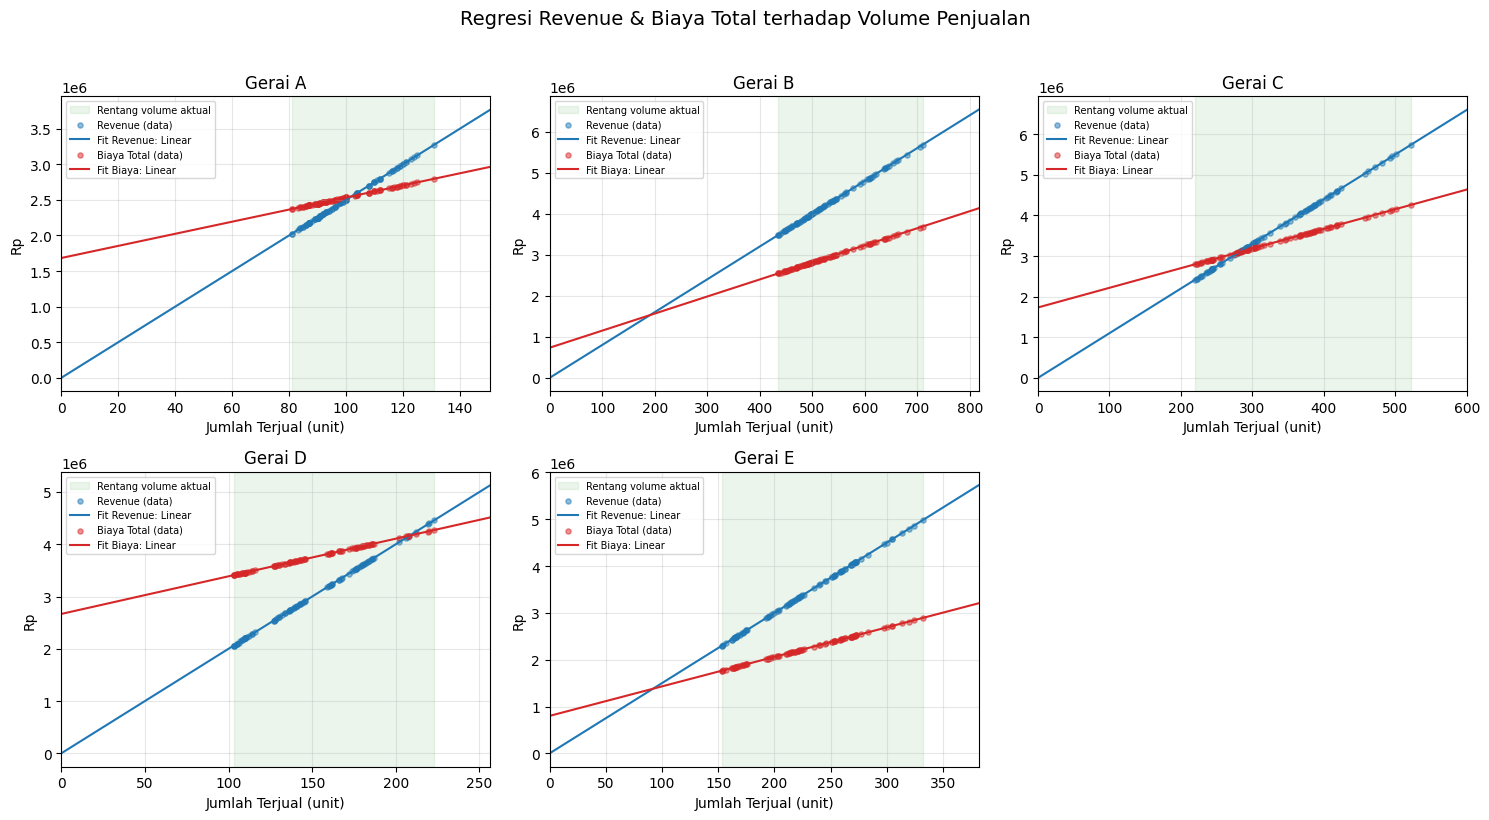

In [ ]:
# Visualisasi hasil regresi: data asli (scatter) + kurva regresi terbaik, revenue & biaya sekaligus
# Sumbu-x sengaja digambar mulai dari 0 (bukan dari volume minimum data) supaya
# titik potong garis Revenue & Biaya (calon BEP) ikut terlihat, meski titik itu
# berada di luar rentang volume yang pernah benar-benar terjadi.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, g in enumerate(gerai_list):
    ax = axes[i]
    rr, rc = regresi_revenue[g], regresi_biaya[g]
    x_plot = np.linspace(0, rr["x"].max() * 1.15, 200)

    ax.axvspan(rr["x"].min(), rr["x"].max(), color="green", alpha=0.08,
               label="Rentang volume aktual")

    ax.scatter(rr["x"], rr["y"], s=14, alpha=0.5, color="tab:blue", label="Revenue (data)")
    ax.plot(x_plot, rr["fn"](x_plot, *rr["popt"]), color="tab:blue",
            label=f"Fit Revenue: {rr['nama']}")

    ax.scatter(rc["x"], rc["y"], s=14, alpha=0.5, color="tab:red", label="Biaya Total (data)")
    ax.plot(x_plot, rc["fn"](x_plot, *rc["popt"]), color="tab:red",
            label=f"Fit Biaya: {rc['nama']}")

    ax.set_title(g)
    ax.set_xlabel("Jumlah Terjual (unit)")
    ax.set_ylabel("Rp")
    ax.set_xlim(0, x_plot.max())
    ax.legend(fontsize=7)

axes[-1].axis("off")
plt.suptitle("Regresi Revenue & Biaya Total terhadap Volume Penjualan", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi grafik:**

Garis biru (Revenue) dan garis merah (Biaya Total) pada tiap panel adalah hasil
regresi terbaik. Perhatikan tiga hal:

1. Garis merah (Biaya) punya titik potong sumbu-y lebih tinggi dari garis biru —
   ini karena Biaya Total mengandung *fixed cost* yang tetap dibayar walau volume
   penjualan = 0, sedangkan Revenue = 0 ketika volume = 0.
2. Kemiringan garis biru (harga jual/unit) pada semua gerai lebih curam daripada
   kemiringan garis merah (biaya variabel/unit) — artinya tiap unit terjual selalu
   memberi kontribusi laba (margin) positif. Kalau tidak demikian, gerai itu tidak akan
   mungkin balik modal berapa pun volumenya.
3. Titik di mana garis biru memotong garis merah adalah gambaran visual dari
   *Break-Even Point* yang akan dihitung presisinya secara numerik pada bagian
   selanjutnya. Semakin jauh titik potong itu ke kanan (butuh volume besar), semakin
   berat syarat sebuah gerai untuk balik modal.

## 4. Pencarian Akar untuk Break-Even Point

**Break-Even Point (BEP)** adalah volume penjualan $x^*$ di mana Revenue sama dengan
Biaya Total, atau dengan kata lain akar dari:

$$f(x) = \text{Revenue}(x) - \text{Biaya Total}(x) = 0$$

di mana $\text{Revenue}(x)$ dan $\text{Biaya Total}(x)$ adalah fungsi hasil regresi
pada bagian sebelumnya (untuk data ini keduanya sama-sama linear, sehingga secara teori
$f(x)$ juga linear dan hanya punya satu akar).

Dua metode numerik diimplementasikan manual (tanpa memanggil `scipy.optimize` untuk
solve, hanya dipakai untuk *validasi* di akhir):

- **Metode Bisection** — mencari akar dengan membagi dua interval $[a,b]$ yang diketahui
  berganti tanda, iteratif hingga toleransi tercapai. Lambat tapi selalu konvergen bila
  bracket valid.
- **Metode Newton-Raphson** — iterasi $x_{n+1} = x_n - f(x_n)/f'(x_n)$, dengan $f'(x)$
  didekati dengan turunan numerik (central difference). Konvergensi jauh lebih cepat,
  namun butuh tebakan awal yang cukup baik.

In [ ]:
def bisection(f, a, b, tol=1e-6, max_iter=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) dan f(b) harus berbeda tanda (tidak ada akar terjamin di [a,b]).")
    riwayat = []
    for i in range(max_iter):
        m = (a + b) / 2
        fm = f(m)
        riwayat.append((i + 1, a, b, m, fm))
        if abs(fm) < tol or (b - a) / 2 < tol:
            return m, riwayat
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return m, riwayat


def turunan_numerik(f, x, h=1e-4):
    return (f(x + h) - f(x - h)) / (2 * h)


def newton_raphson(f, x0, tol=1e-6, max_iter=100):
    x = x0
    riwayat = [(0, x, f(x))]
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < tol:
            return x, riwayat
        dfx = turunan_numerik(f, x)
        if dfx == 0:
            raise ZeroDivisionError("Turunan nol, Newton-Raphson gagal konvergen.")
        x = x - fx / dfx
        riwayat.append((i + 1, x, f(x)))
    return x, riwayat


def cari_bracket(f, x_min, x_max, n=3000):
    """Scan rentang [x_min, x_max] untuk menemukan interval pertama dengan pergantian tanda."""
    xs = np.linspace(x_min, x_max, n)
    fs = f(xs)
    for i in range(len(xs) - 1):
        if fs[i] == 0:
            return xs[i], xs[i]
        if fs[i] * fs[i + 1] < 0:
            return xs[i], xs[i + 1]
    return None


Blok kode ini mendefinisikan algoritma metode numerik (Bisection dan Newton-Raphson) beserta pembantunya (bracket search dan turunan numerik). Tujuannya adalah untuk menghitung lokasi angka pasti volume penjualan pada titik balik modal (break-even point) secara presisi tinggi melalui proses iterasi matematis.

In [ ]:
hasil_bep = []

for g in gerai_list:
    rr, rc = regresi_revenue[g], regresi_biaya[g]
    fn_r, popt_r = rr["fn"], rr["popt"]
    fn_c, popt_c = rc["fn"], rc["popt"]

    f = lambda x: fn_r(x, *popt_r) - fn_c(x, *popt_c)

    x_min_data, x_max_data = rr["x"].min(), rr["x"].max()
    bracket = cari_bracket(f, 0, x_max_data * 1.5)

    if bracket is None:
        hasil_bep.append({
            "Gerai": g, "Model Revenue": rr["nama"], "Model Biaya": rc["nama"],
            "BEP (Bisection)": np.nan, "Iterasi Bisection": np.nan,
            "BEP (Newton-Raphson)": np.nan, "Iterasi Newton": np.nan,
            "Validasi (brentq)": np.nan,
            "Status": "Tidak ada akar pada rentang volume yang diamati"
        })
        continue

    a, b = bracket
    x_bis, hist_bis = bisection(f, a, b)
    x0 = (a + b) / 2
    x_new, hist_new = newton_raphson(f, x0)
    x_valid = brentq(f, a, b)

    status = "Di dalam rentang volume aktual" if x_min_data <= x_bis <= x_max_data \
             else ("Di bawah rentang aktual (selalu untung)" if x_bis < x_min_data
                   else "Di atas rentang aktual (selalu rugi)")

    hasil_bep.append({
        "Gerai": g, "Model Revenue": rr["nama"], "Model Biaya": rc["nama"],
        "BEP (Bisection)": round(x_bis, 2), "Iterasi Bisection": len(hist_bis),
        "BEP (Newton-Raphson)": round(x_new, 2), "Iterasi Newton": len(hist_new),
        "Validasi (brentq)": round(x_valid, 2),
        "Status": status
    })

df_bep = pd.DataFrame(hasil_bep)
df_bep


,Gerai,Model Revenue,Model Biaya,BEP (Bisection),Iterasi Bisection,BEP (Newton-Raphson),Iterasi Newton,Validasi (brentq),Status
0,Gerai A,Linear,Linear,102.02,16,102.02,2,102.02,Di dalam rentang volume aktual
1,Gerai B,Linear,Linear,190.97,19,190.97,2,190.97,Di bawah rentang aktual (selalu untung)
2,Gerai C,Linear,Linear,281.39,18,281.39,2,281.39,Di dalam rentang volume aktual
3,Gerai D,Linear,Linear,208.33,17,208.33,2,208.33,Di dalam rentang volume aktual
4,Gerai E,Linear,Linear,91.95,18,91.95,2,91.95,Di bawah rentang aktual (selalu untung)


In [ ]:
# --- Interpretasi otomatis hasil BEP ---
print("INTERPRETASI TITIK IMPAS (BEP):\n")
for _, row in df_bep.iterrows():
    g = row["Gerai"]
    sub = df[df["Gerai"] == g]
    vmin, vmax, vmean = sub["Jumlah Terjual (Unit)"].min(), sub["Jumlah Terjual (Unit)"].max(), sub["Jumlah Terjual (Unit)"].mean()
    bep = row["BEP (Bisection)"]

    # cek konsistensi bisection vs newton vs brentq (harusnya identik s.d. pembulatan)
    selisih = abs(row["BEP (Bisection)"] - row["BEP (Newton-Raphson)"])
    konsistensi = "konsisten (selisih < 0.01 unit)" if selisih < 0.01 else f"berselisih {selisih:.3f} unit -- perlu dicek ulang"

    print(f"{g}: BEP = {bep:.1f} unit/hari  |  volume aktual harian: {vmin}-{vmax} (rata-rata {vmean:.0f})")
    print(f"   Bisection butuh {row['Iterasi Bisection']:.0f} iterasi, Newton-Raphson hanya {row['Iterasi Newton']:.0f} iterasi "
          f"untuk toleransi yang sama -> {konsistensi}.")
    if bep < vmin:
        margin = vmin - bep
        print(f"   -> BEP berada DI BAWAH volume terendah yang pernah tercatat (margin aman {margin:.0f} unit). "
              f"Gerai ini secara historis SELALU berada di atas titik impas.")
    elif bep > vmax:
        kurang = bep - vmax
        print(f"   -> BEP berada DI ATAS volume tertinggi yang pernah tercatat (kurang {kurang:.0f} unit lagi). "
              f"Gerai ini belum pernah mencapai titik impas dalam periode data ini -> berisiko tinggi.")
    else:
        pct_hari_untung = (sub['Jumlah Terjual (Unit)'] >= bep).mean() * 100
        print(f"   -> BEP berada DI DALAM rentang volume aktual: sekitar {pct_hari_untung:.0f}% dari hari-hari yang "
              f"tercatat memiliki volume di atas BEP (untung), sisanya di bawah BEP (rugi).")
    print()


INTERPRETASI TITIK IMPAS (BEP):

Gerai A: BEP = 102.0 unit/hari  |  volume aktual harian: 81-131 (rata-rata 99)
   Bisection butuh 16 iterasi, Newton-Raphson hanya 2 iterasi untuk toleransi yang sama -> konsisten (selisih < 0.01 unit).
   -> BEP berada DI DALAM rentang volume aktual: sekitar 34% dari hari-hari yang tercatat memiliki volume di atas BEP (untung), sisanya di bawah BEP (rugi).

Gerai B: BEP = 191.0 unit/hari  |  volume aktual harian: 435-710 (rata-rata 528)
   Bisection butuh 19 iterasi, Newton-Raphson hanya 2 iterasi untuk toleransi yang sama -> konsisten (selisih < 0.01 unit).
   -> BEP berada DI BAWAH volume terendah yang pernah tercatat (margin aman 244 unit). Gerai ini secara historis SELALU berada di atas titik impas.

Gerai C: BEP = 281.4 unit/hari  |  volume aktual harian: 220-522 (rata-rata 329)
   Bisection butuh 18 iterasi, Newton-Raphson hanya 2 iterasi untuk toleransi yang sama -> konsisten (selisih < 0.01 unit).
   -> BEP berada DI DALAM rentang volume aktual

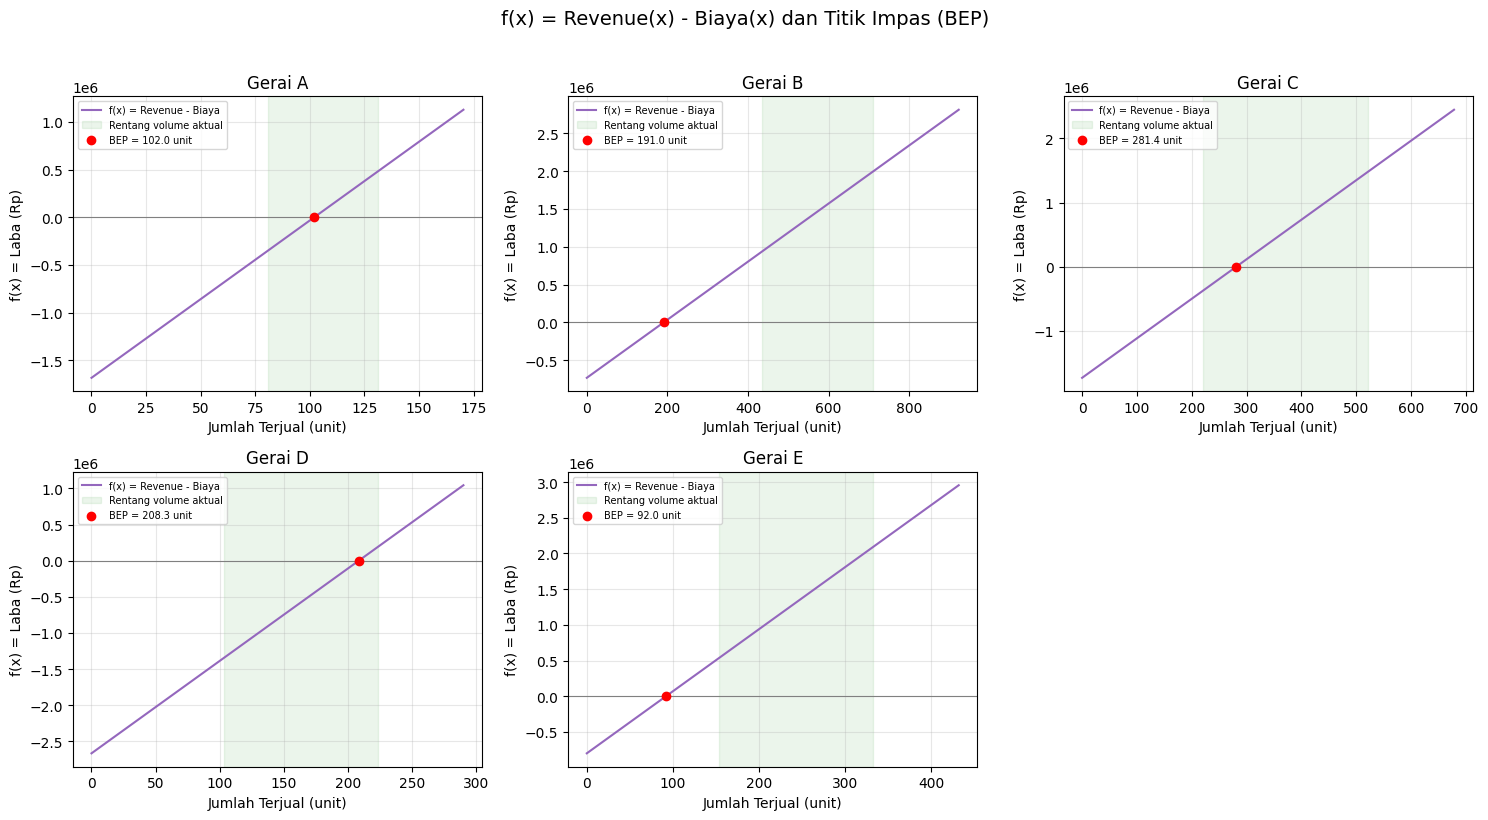

In [ ]:
# Visualisasi f(x) = Revenue(x) - Biaya(x) dan lokasi BEP untuk setiap gerai
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, g in enumerate(gerai_list):
    rr, rc = regresi_revenue[g], regresi_biaya[g]
    fn_r, popt_r = rr["fn"], rr["popt"]
    fn_c, popt_c = rc["fn"], rc["popt"]
    f = lambda x: fn_r(x, *popt_r) - fn_c(x, *popt_c)

    row = df_bep[df_bep["Gerai"] == g].iloc[0]
    x_max_plot = max(rr["x"].max() * 1.3, (row["BEP (Bisection)"] or rr["x"].max()) * 1.2)
    x_plot = np.linspace(0, x_max_plot, 300)

    ax = axes[i]
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.plot(x_plot, f(x_plot), color="tab:purple", label="f(x) = Revenue - Biaya")
    ax.axvspan(rr["x"].min(), rr["x"].max(), color="green", alpha=0.08, label="Rentang volume aktual")

    if not pd.isna(row["BEP (Bisection)"]):
        ax.scatter([row["BEP (Bisection)"]], [0], color="red", zorder=5,
                   label=f"BEP = {row['BEP (Bisection)']:.1f} unit")

    ax.set_title(g)
    ax.set_xlabel("Jumlah Terjual (unit)")
    ax.set_ylabel("f(x) = Laba (Rp)")
    ax.legend(fontsize=7)

axes[-1].axis("off")
plt.suptitle("f(x) = Revenue(x) - Biaya(x) dan Titik Impas (BEP)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


- Sumbu-y sekarang adalah **f(x) = Revenue(x) − Biaya(x)**, yang sebenarnya adalah
  estimasi laba/rugi harian pada volume x tertentu.
- Kurva di bawah garis nol (abu-abu) berarti rugi pada volume itu; di atas garis
  nol berarti untung.
- Titik merah adalah akar dari f(x) — yaitu BEP yang ditemukan lewat Bisection/Newton.
- Area hijau transparan menunjukkan rentang volume yang benar-benar pernah terjadi
  di data historis gerai tersebut. Kalau titik merah jatuh di luar area hijau (baik
  di kiri/bawah rentang maupun di kanan/atas rentang), itu artinya gerai tersebut secara
  historis konsisten (selalu untung atau justru selalu rugi). Kalau titik merah jatuh
  di dalam area hijau, artinya performa gerai itu naik-turun melewati titik impas
  dari hari ke hari — sebagian hari untung, sebagian rugi.

## 5. Kesimpulan & Interpretasi Bisnis


- **Gerai A (Premium Gourmet)** — margin per unit besar (harga tinggi) sehingga BEP dapat
  dicapai dengan volume relatif kecil. Namun karena target pasarnya niche, volume harian
  aktualnya juga kecil, jadi gerai ini tetap rentan rugi pada hari-hari penjualan sepi.
- **Gerai B (Mass Market Volume)** — margin per unit tipis (harga murah, biaya bahan naik
  akibat inflasi), sehingga BEP membutuhkan volume yang sangat besar. Model ini hanya
  layak jika volume penjualan bisa dijaga tinggi secara konsisten.
- **Gerai C (Promo Agresif)** — diskon awal menurunkan margin efektif sehingga BEP
  membutuhkan volume tambahan untuk menutup biaya iklan; strategi ini biasanya
  ditujukan untuk membangun basis pelanggan terlebih dulu sebelum profit stabil.
- **Gerai D (Mall Premium Flagship)** — meski margin per unit cukup baik, sewa lokasi
  (fixed cost) yang tinggi mendorong BEP naik signifikan, sehingga gerai ini paling
  sensitif terhadap penurunan trafik mall.
- **Gerai E (Cloud Kitchen)** — komisi platform 18% memangkas margin per unit, tetapi
  fixed cost yang jauh lebih rendah dibanding gerai fisik membuat BEP tetap relatif rendah.

Dari kelima profil tersebut, Gerai E (Cloud Kitchen) adalah yang paling direkomendasikan secara operasional dan risiko bisnis, diikuti oleh Gerai A sebagai pilihan kedua.

  
